In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp
from sympy.polys.polyfuncs import interpolate
from matplotlib.pyplot import figure
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator
import ipywidgets as widgets
from ipywidgets import interact
from scipy.interpolate import UnivariateSpline
from IPython.display import display, Math
from scipy.special import roots_legendre
from decimal import Decimal, getcontext
import math
from functools import lru_cache
import sys
from PIL import Image

# Задание 1. Фурье-преобразование картинки.

Сделайте преобразование Фурье от картинки в файле im1.jpg, используя файл rian.py. Сохраните двумерный фурье-образ в файле out.jpg (параметры цвета r, g, b округлять до целых чисел). Удалите из фурье-образа верхнюю половину пространственных частот по каждой координате. Сделайте обратное преобразование и сохраните в файле out2.jpg

Указание.

Методом двумерного преобразования Фурье (two-dimensional Fourier transform - 2-DFT) является преобразование Фурье, произведенное над двумерным массивом данных. Рассмотрим двумерный массив данных. Эти данные имеют два измерения: x и y. Преобразование Фурье над данными производится сначала в одном, а затем в другом направлениях.

Первая часть преобразования Фурье проводится в x измерении. Вторая часть преобразования Фурье производится в y измерении.

In [191]:
im = Image.open("data/im1.jpg")
pixels = np.asarray(im)

ft = np.fft.fft2(pixels, axes=(0, 1))

out = Image.fromarray(np.uint8(abs(ft)/(ft.shape[0]*ft.shape[1])))
out.save('data/out.jpg')

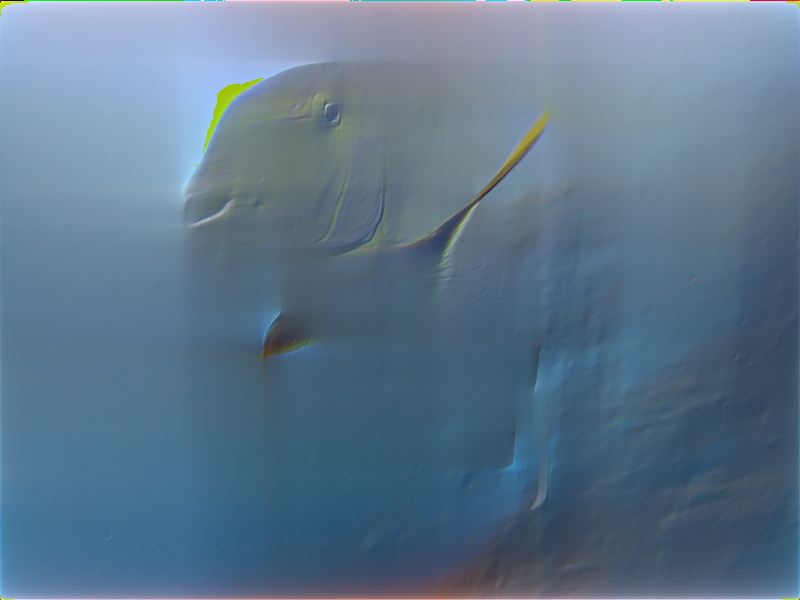

In [192]:
ft[ift.shape[0]//2:, :, :] = 0
ft[:, ift.shape[1]//2:, :] = 0

ift = np.fft.ifft2(ft, axes=(0, 1))

out2 = Image.fromarray(np.uint8(np.abs(ift)))
out2.save('data/out2.jpg')

out2

# Задание 2. Фурье-преобразование звука.

Возьмите файл in10.wav и, используя sound.py, добавьте в его фурье-образ низкочастотный шум. Сохраните результат в out1.wav. После этого обрежьте нижние частоты в фурье-образе и сохраните в out2.wav.

In [607]:
import scipy.io.wavfile as wavfile
import wave
import pylab as pl
import numpy as np
import struct
import matplotlib as mp

In [608]:
def format_time(x, pos=None):
    global duration, nframes, k
    progress = int(x / float(nframes) * duration * k)
    mins, secs = divmod(progress, 60)
    hours, mins = divmod(mins, 60)
    out = "%d:%02d" % (mins, secs)
    if hours > 0:
        out = "%d:" % hours
    return out

def format_db(x, pos=None):
    if pos == 0:
        return ""
    global peak
    if x == 0:
        return "-inf"

    db = 20 * math.log10(abs(x) / float(peak))
    return int(db)


In [609]:
with wave.open("data/in10.wav", mode="r") as wav:
    (nchannels, sampwidth, framerate, nframes, comptype, compname) = wav.getparams()
    content = wav.readframes(nframes)

In [610]:
types = {
    1: np.int8,
    2: np.int16,
    4: np.int32
}

C:\Users\Eldar\AppData\Local\Temp\ipykernel_17948\1621973723.py:1: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  samples = np.fromstring(content, dtype=types[sampwidth])


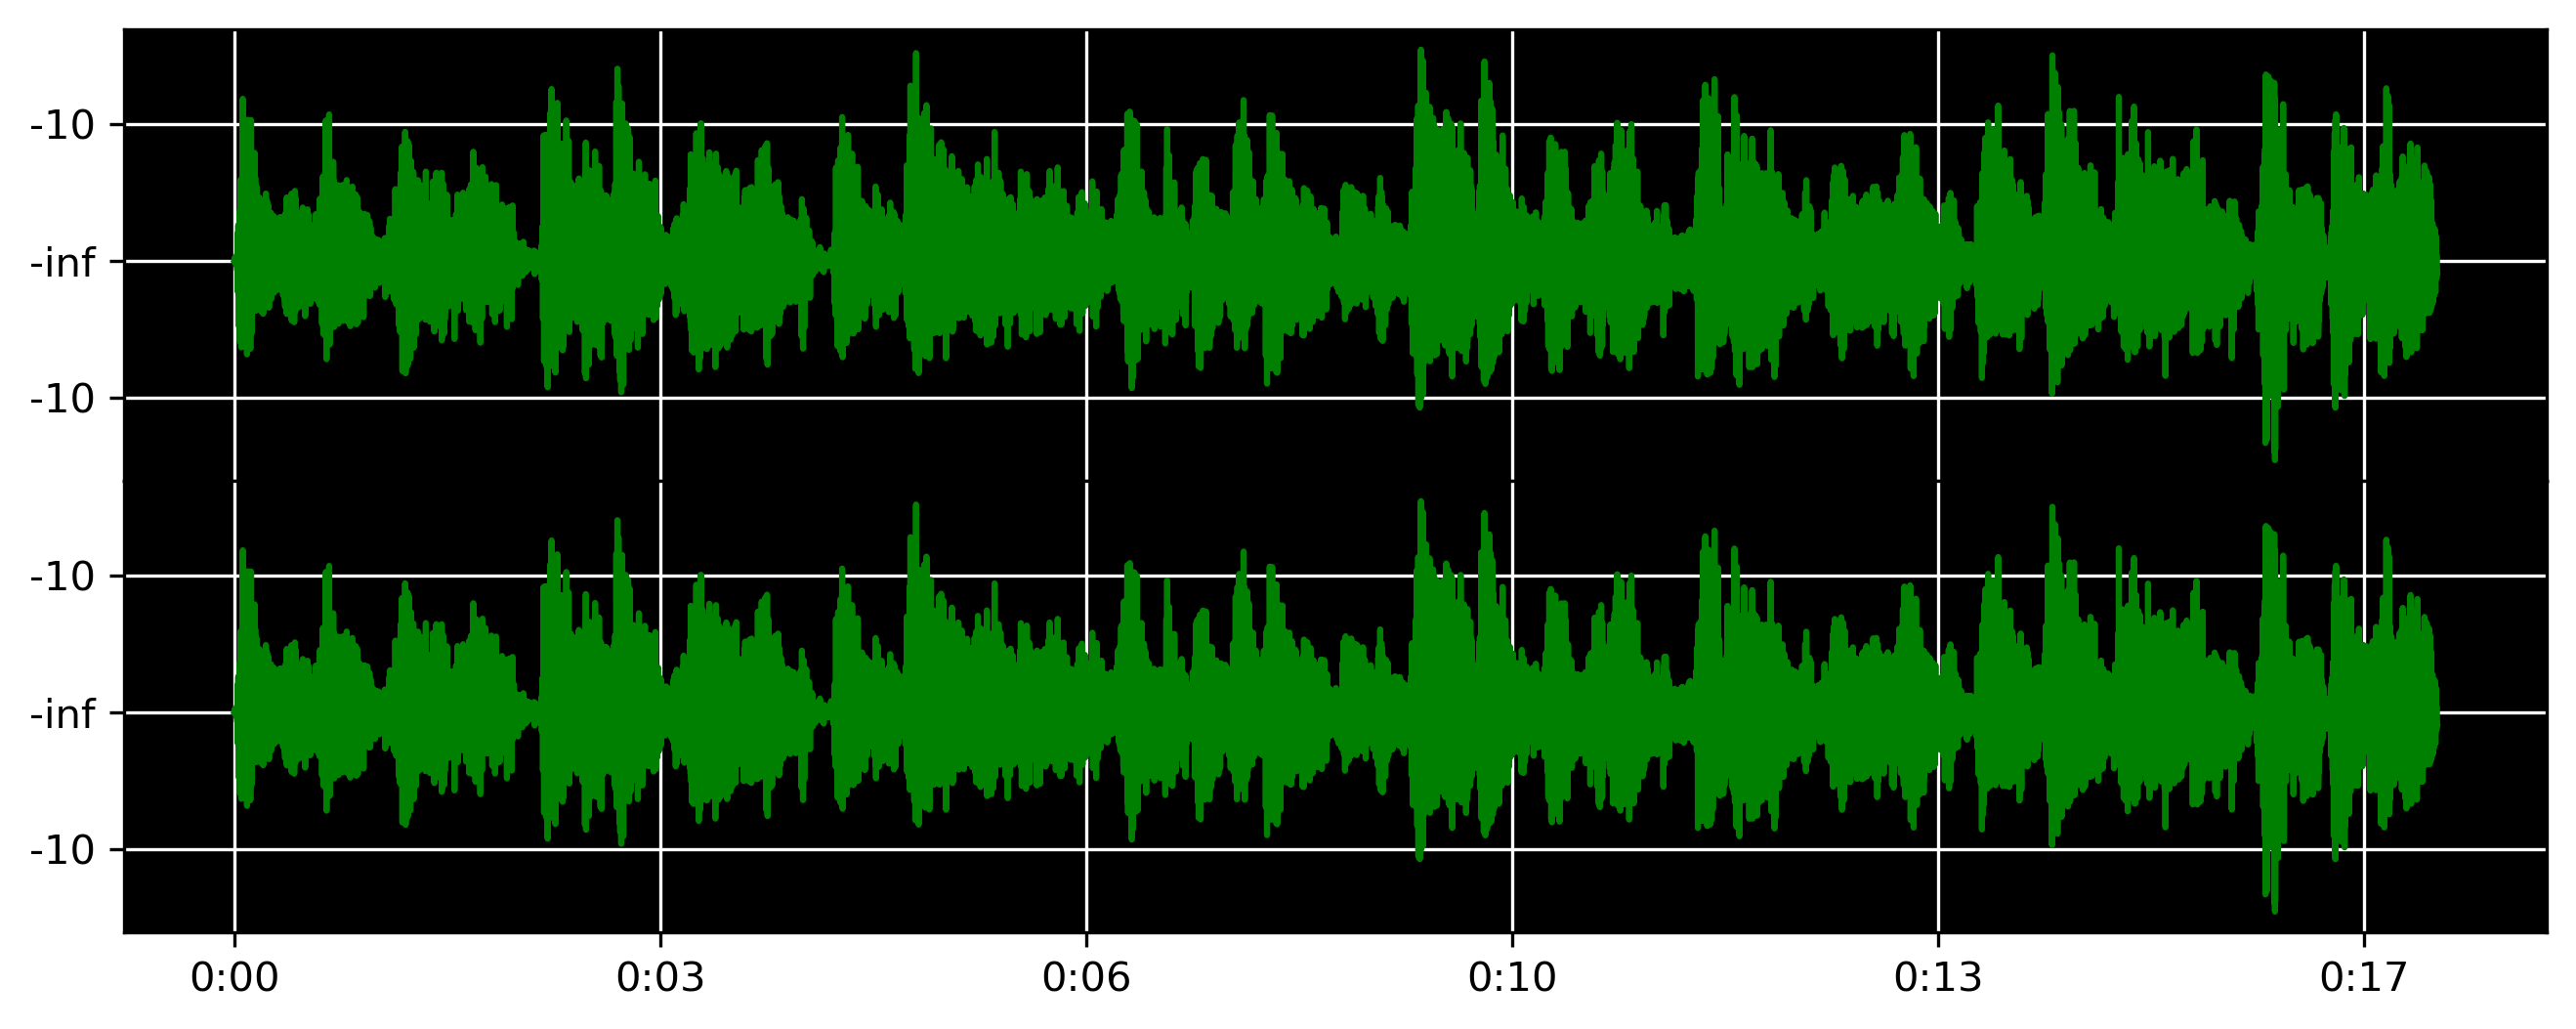

In [611]:
samples = np.fromstring(content, dtype=types[sampwidth])
duration = nframes / framerate 
w, h = 800, 300
DPI = 300
peak = 256 ** sampwidth / 2
k = int(nframes/w/32)

plt.figure(1, figsize=(4*float(w)/DPI, 4*float(h)/DPI), dpi=DPI)
plt.subplots_adjust(wspace=0, hspace=0) 

for n in range(nchannels):
    channel = samples[n::nchannels]

    channel = channel[0::k]
    if nchannels == 1:
        channel = channel - peak
  
    axes = plt.subplot(2, 1, n+1, facecolor="k")
    axes.plot(channel, "g")
    axes.yaxis.set_major_formatter(mp.ticker.FuncFormatter(format_db))
    plt.grid(True, color="w")
    axes.xaxis.set_major_formatter(mp.ticker.NullFormatter())

axes.xaxis.set_major_formatter(mp.ticker.FuncFormatter(format_time))

plt.savefig("data/wave.png", dpi=DPI)
plt.show()

In [630]:
ft = []
freq = []
tpCount = []

for n in range(nchannels):
    data = samples[n::nchannels]

    tpCount.append(len(data))

    original_SR = len(samples)/duration
    new_time_period = tpCount[n]*nchannels/samplingFrequency

    new_SR = tpCount[n]/new_time_period

    ft.append(np.fft.rfft(data)/tpCount[n])
    freq.append(np.fft.rfftfreq(tpCount[n], 1/new_SR))

In [631]:
noise_amp = 50
noise_max_freq = 5

ft_w_noise = []

for n in range(nchannels):
    freq_rate = freq[n][-1]/len(freq[n])
    noise_size = int(noise_max_freq/freq_rate)

    noise = np.random.uniform(-1*noise_amp, noise_amp, noise_size)
    
    ft_w_noise.append(ft[n].copy())
    
    for i in range(len(noise)):
        amp = abs(ft_w_noise[n][i])
        ft_w_noise[n][i] *= 1 + noise[i]/amp

In [632]:
ift = []

for n in range(nchannels):
    ift.append(np.fft.irfft(ft_w_noise[n]*tpCount[n]))

In [633]:
max_low_freq = 5

for n in range(len(ft_wo_low)):
    freq_rate = freq[n][-1]/len(freq[n])
    low_freq_size = int(max_low_freq/freq_rate)
    
    ft_wo_low[n] = ft[n].copy()
    
    for i in range(low_freq_size):
        ft_wo_low[n][i] = 0

In [634]:
ift2 = []

for n in range(nchannels):
    ift2.append(np.fft.irfft(ft_wo_low[n]*tpCount[n]))

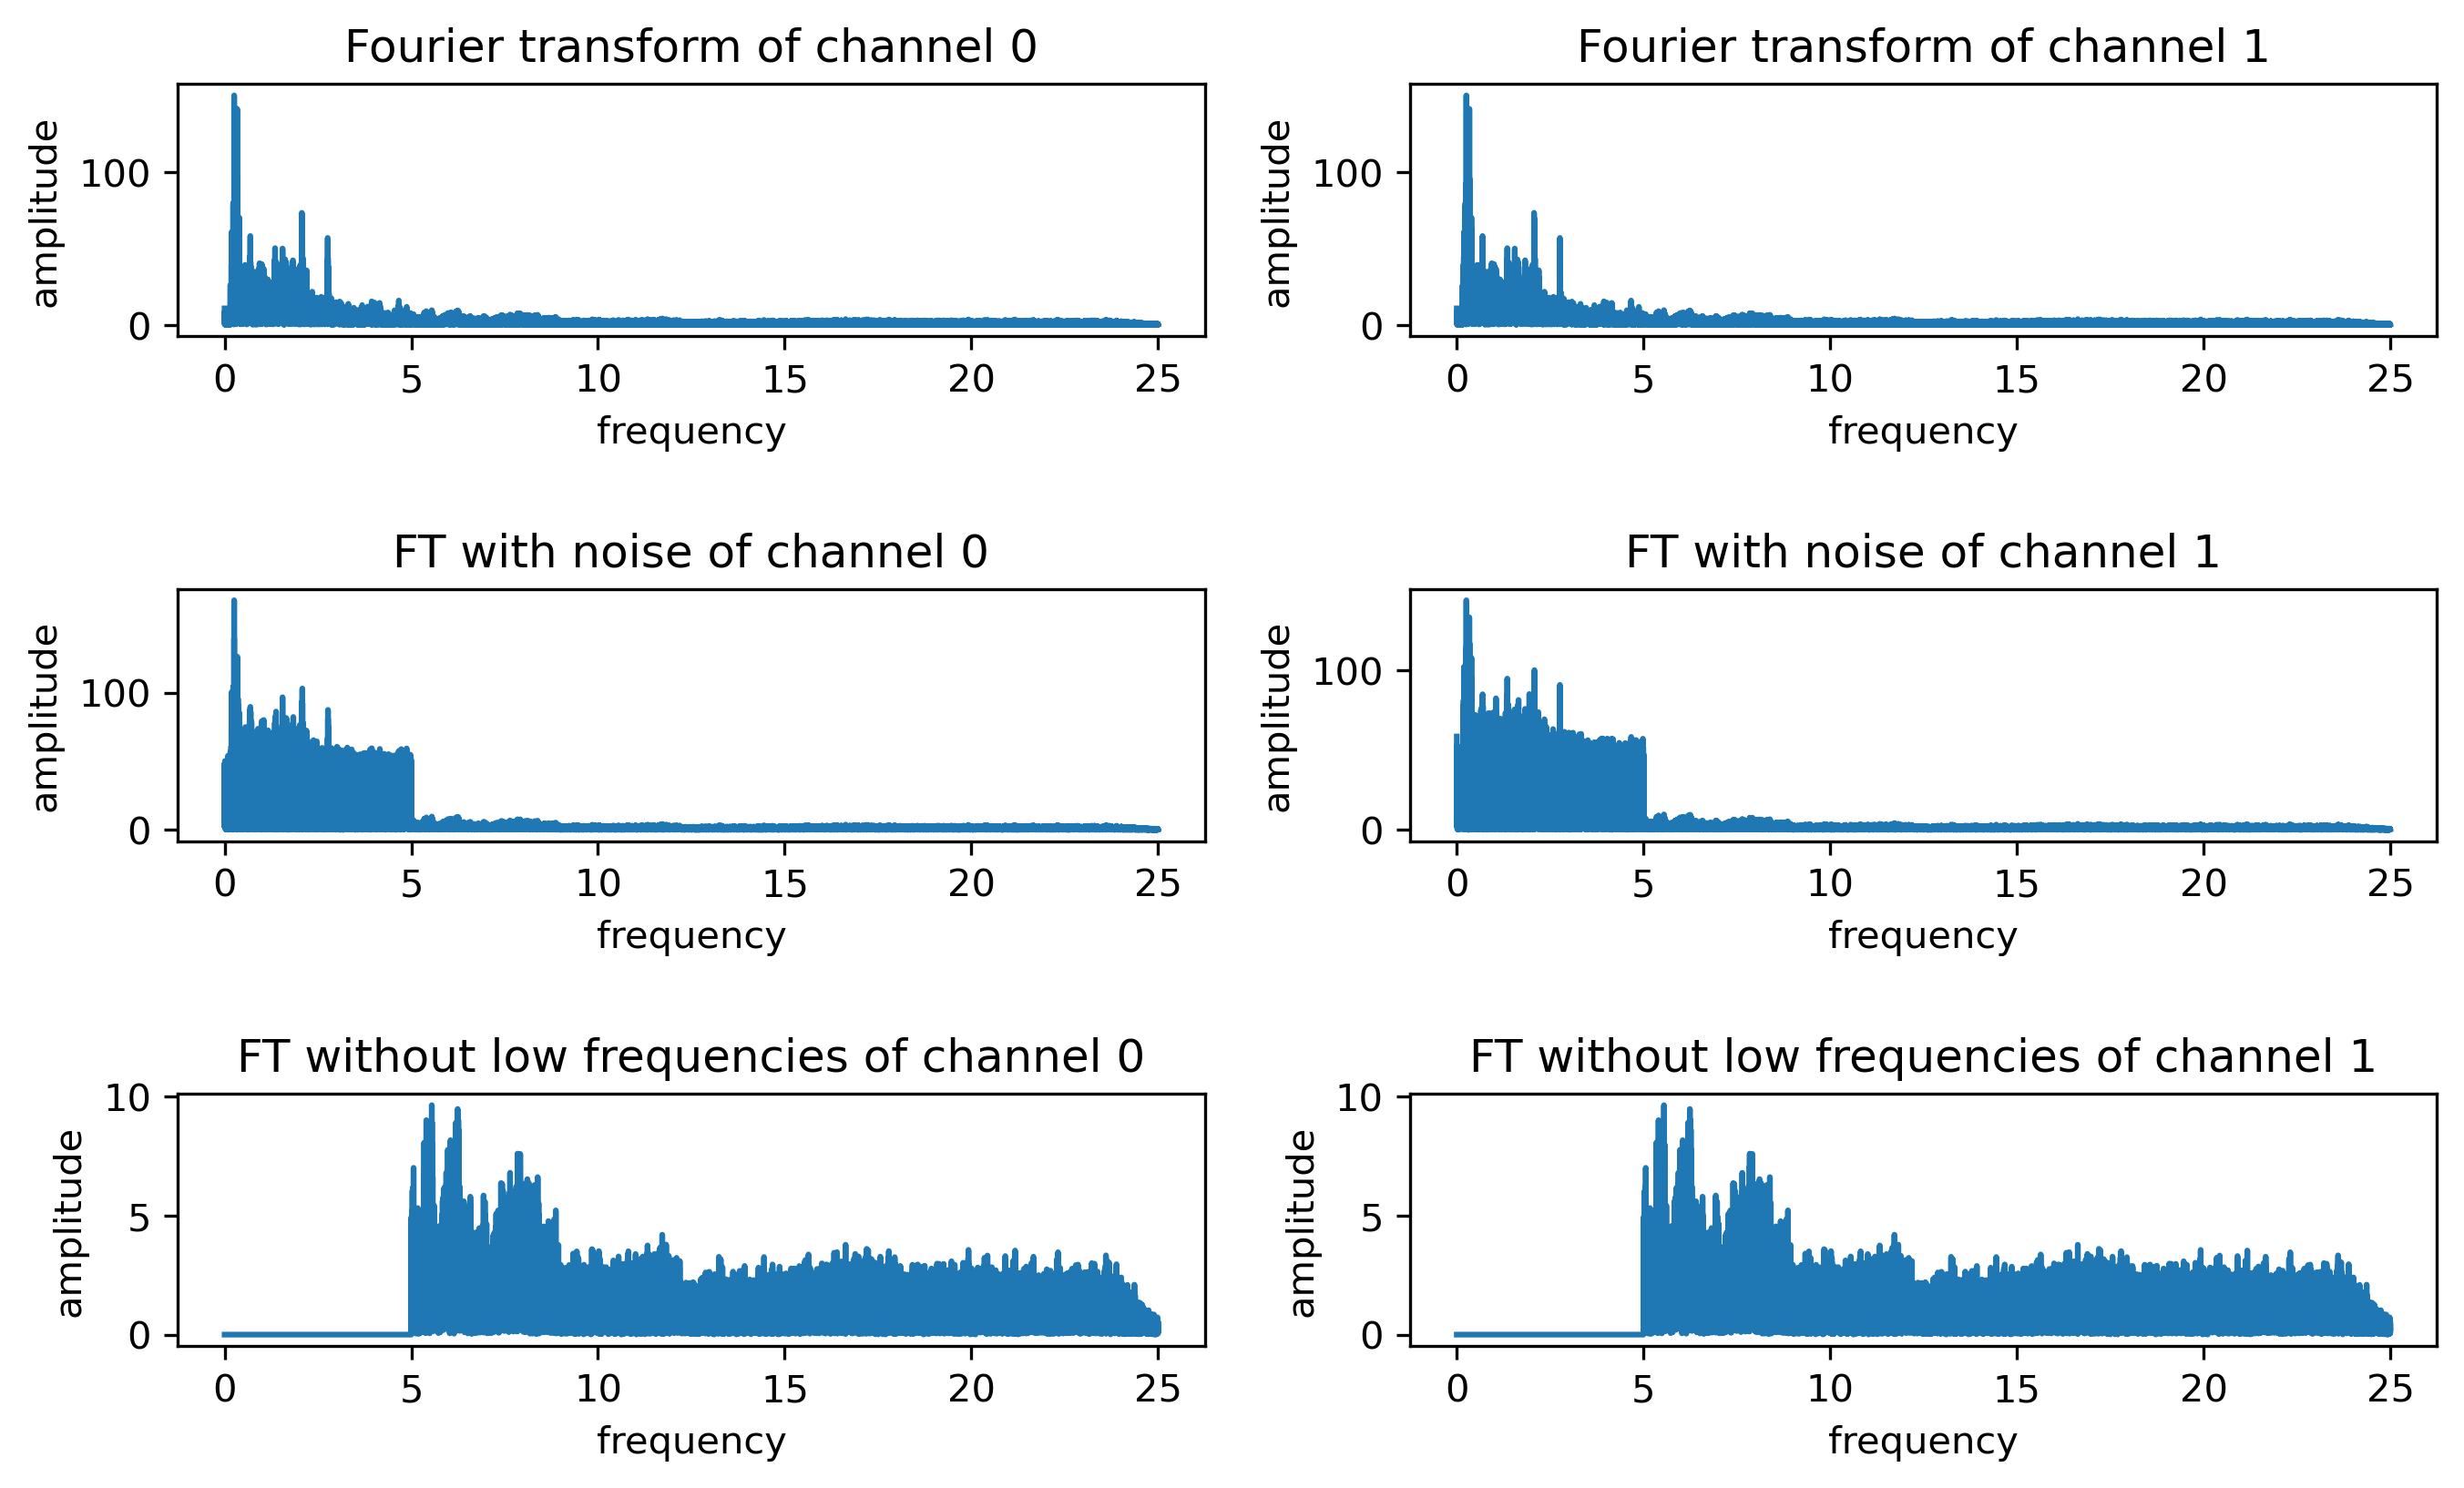

In [635]:
plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
plt.subplots_adjust(wspace=0.2, hspace=1) 

for n in range(nchannels):
    axes = plt.subplot(3, 2, n+1)
    axes.plot(freq[n], np.abs(ft[n]))
    axes.set_xlabel('frequency')
    axes.set_ylabel('amplitude')
    axes.set_title(f'Fourier transform of channel {n}')
    
    axes = plt.subplot(3, 2, n+3)
    axes.plot(freq[n], np.abs(ft_w_noise[n]))
    axes.set_xlabel('frequency')
    axes.set_ylabel('amplitude')
    axes.set_title(f'FT with noise of channel {n}')
    
    axes = plt.subplot(3, 2, n+5)
    axes.plot(freq[n], np.abs(ft_wo_low[n]))
    axes.set_xlabel('frequency')
    axes.set_ylabel('amplitude')
    axes.set_title(f'FT without low frequencies of channel {n}')
    
plt.show()

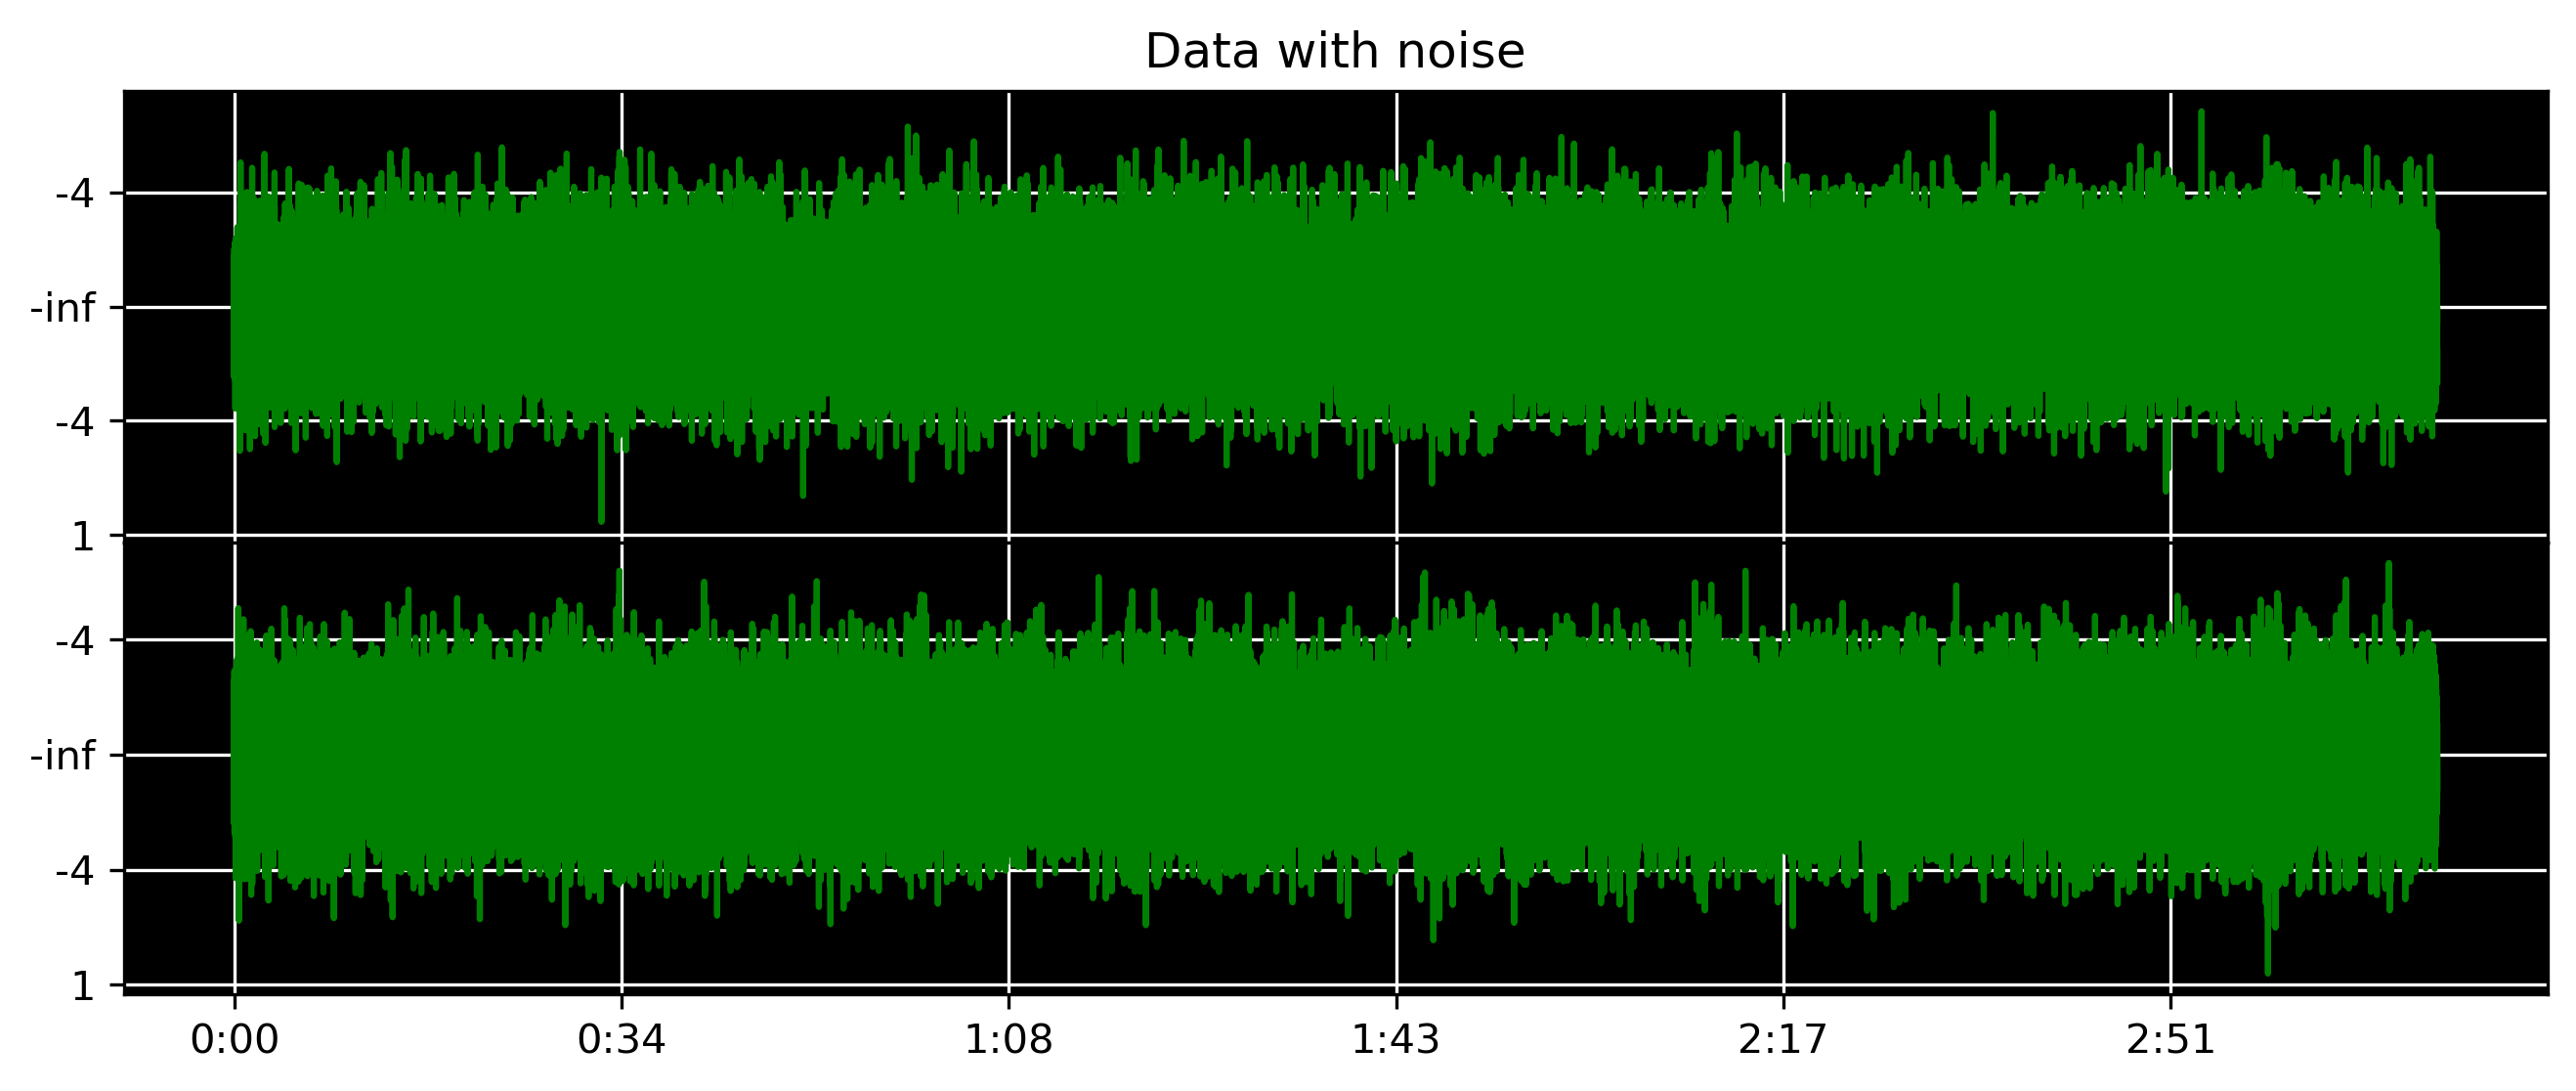

In [636]:
plt.figure(1, figsize=(4*float(w)/DPI, 4*float(h)/DPI), dpi=DPI)
plt.subplots_adjust(wspace=0, hspace=0) 

for n in range(nchannels):
    axes = plt.subplot(2, 1, n+1, facecolor="k")
    axes.plot(ift[n], "g")
    axes.yaxis.set_major_formatter(mp.ticker.FuncFormatter(format_db))
    plt.grid(True, color="w")
    axes.xaxis.set_major_formatter(mp.ticker.NullFormatter())
    
axes.xaxis.set_major_formatter(mp.ticker.FuncFormatter(format_time))

plt.savefig("data/wave_with_noise.png", dpi=DPI)
plt.title('Data with noise', y=2)
plt.show()

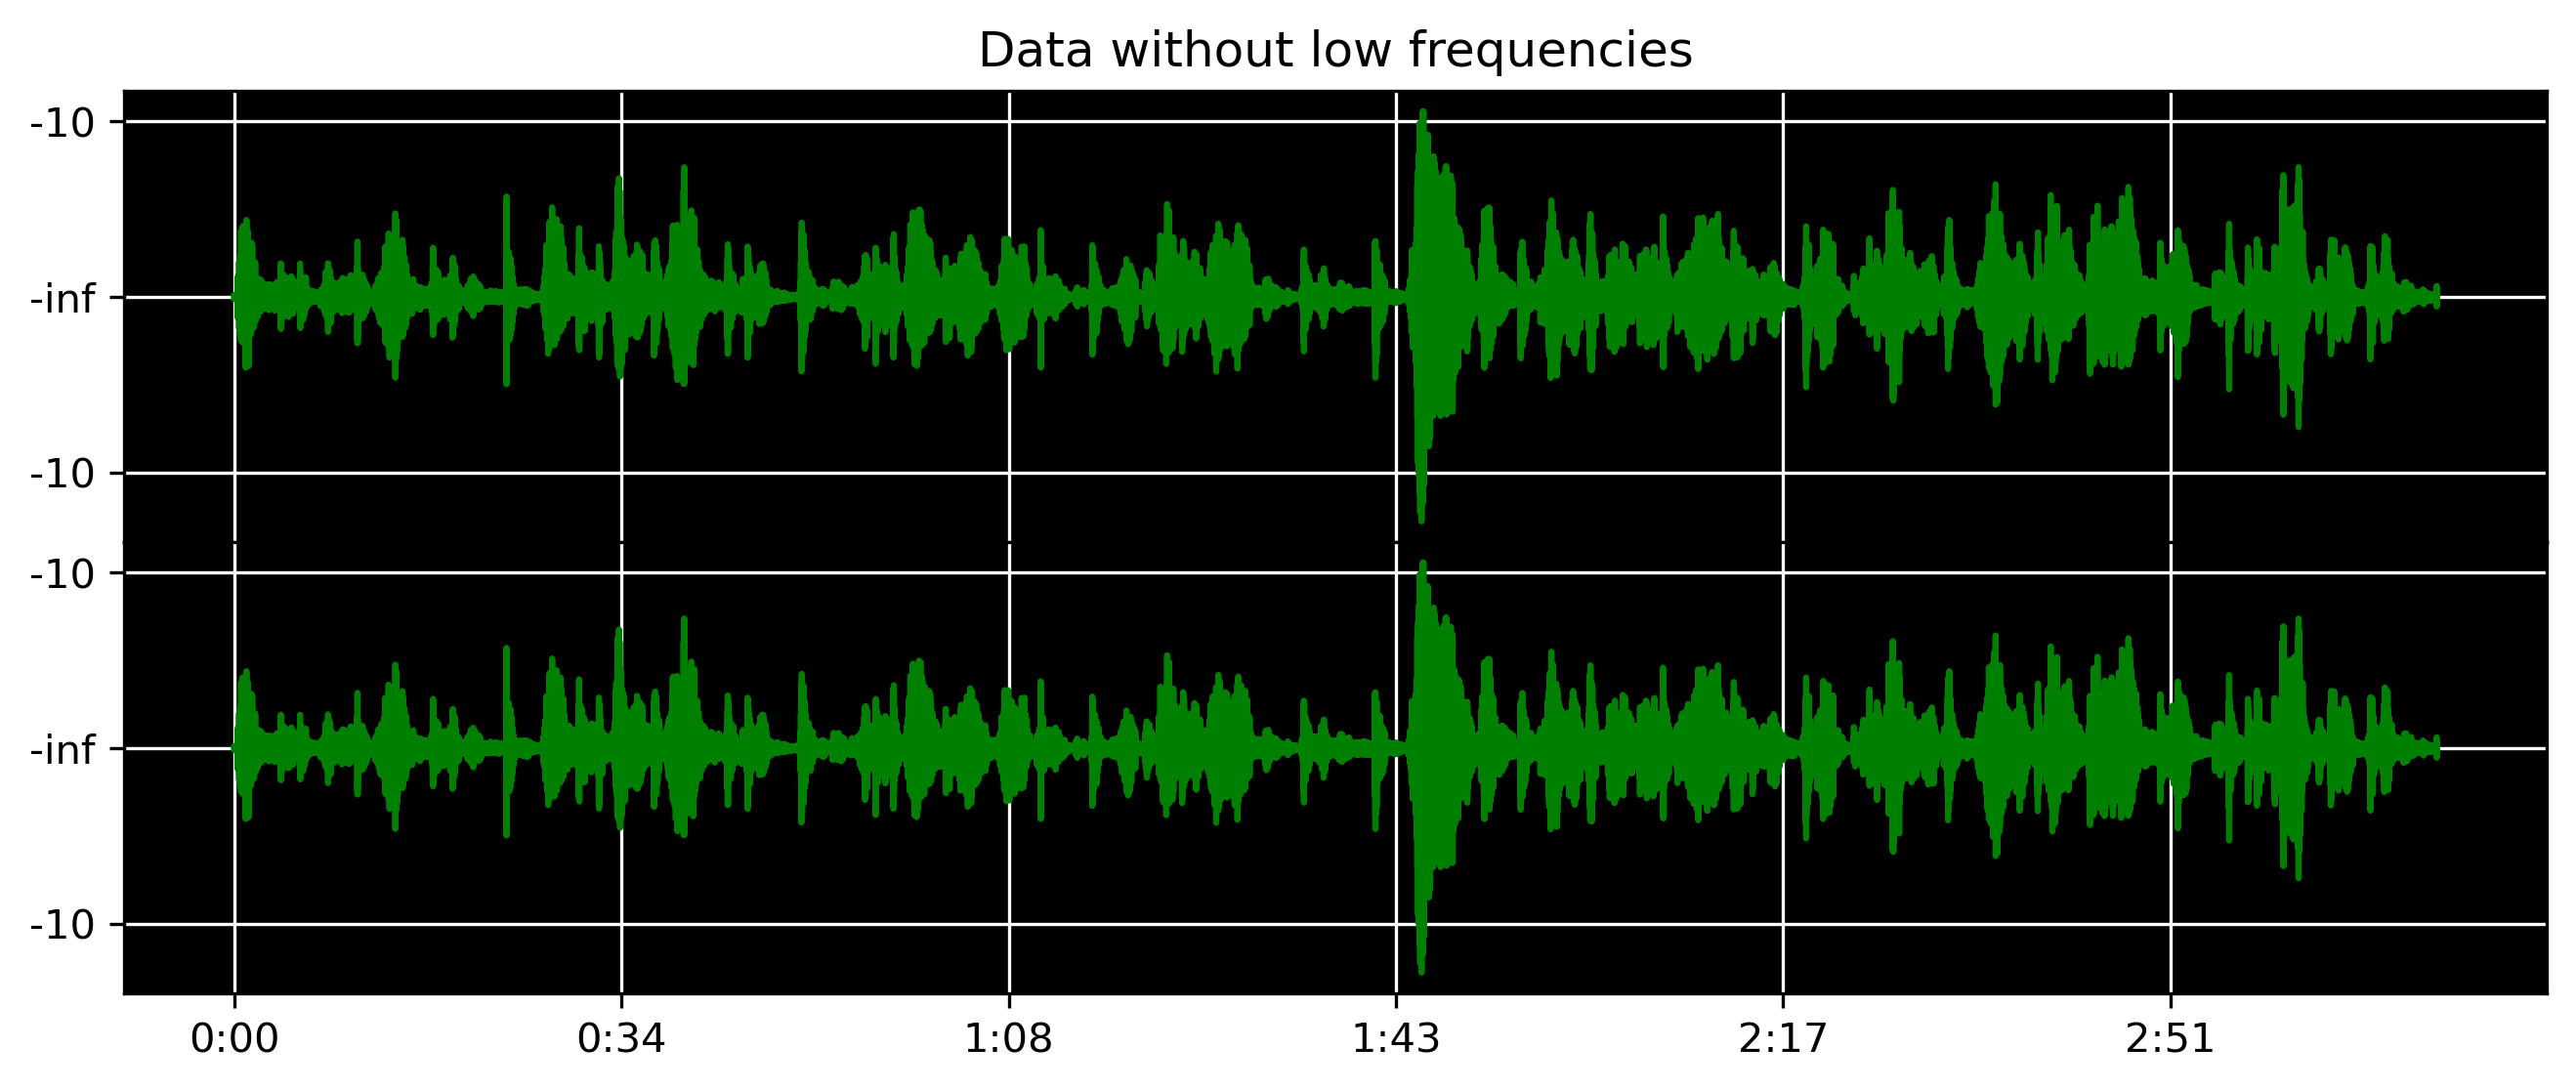

In [637]:
plt.figure(1, figsize=(4*float(w)/DPI, 4*float(h)/DPI), dpi=DPI)
plt.subplots_adjust(wspace=0, hspace=0) 

for n in range(nchannels):
    axes = plt.subplot(2, 1, n+1, facecolor="k")
    axes.plot(ift2[n], "g")
    axes.yaxis.set_major_formatter(mp.ticker.FuncFormatter(format_db))
    plt.grid(True, color="w")
    axes.xaxis.set_major_formatter(mp.ticker.NullFormatter())
    
axes.xaxis.set_major_formatter(mp.ticker.FuncFormatter(format_time))

plt.savefig("data/wave_wo_low_freq.png", dpi=DPI)
plt.title('Data without low frequencies', y=2)
plt.show()

In [638]:
def save_data(newdata, path):
    newdata = np.transpose(np.stack(newdata)).flatten().astype(np.int16)
    
    with wave.open(path, mode="wb") as dest:
        dest.setparams(wav.getparams())
        newframes = struct.pack('<' + str(len(newdata)) + 'h', *newdata)
        dest.writeframes(newframes)

In [639]:
save_data(ift, 'data/out.wav')
save_data(ift2, 'data/out2.wav')